# Regularized Regression Tuning

## Notebook Objective

This notebook tunes Ridge and Lasso regression models for monthly cost prediction using cross-validation.

The goal is to improve on manually chosen regularization strength by selecting `alpha` values through `GridSearchCV`.

The tuned Ridge and Lasso models are compared against the baseline Linear Regression model using MAE, RMSE, and R² on a held-out test set.

This notebook focuses on regularization tuning and model comparison, not causal interpretation.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load processed data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")

print(df.shape)
df.head()



(3000, 25)


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define target and features

In [3]:
target = "monthly_cost"  # Define the regression target variable

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns=drop_cols, errors="ignore")  # Create predictors after removing leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors for scaling
).columns.tolist()  # Store numeric column names as a list

categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors for encoding
).columns.tolist()  # Store categorical column names as a list

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Feature count:", X.shape[1])

Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']
Categorical columns: ['gender', 'region', 'plan_type']
Feature count: 11


## Feature Selection Logic

This notebook uses the same cleaned predictor set as the baseline cost regression and regularized regression notebooks.

The model excludes direct leakage fields, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost`.

Grouped variables such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included and are cleaner for interpretation.

Derived utilization variables such as `total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` are excluded because `ed_visits` and `ip_admits` are already included separately.

This keeps the tuning comparison consistent with the earlier baseline regression notebooks.

## 4. Train-test split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # splitting data into training and testing sets (80% train, 20% test)

## 5. Build preprocessing

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),  # Standardize numeric predictors
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)  # One-hot encode categorical predictors
    ]
)

## 6. Build baseline models

In [6]:
linear_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()) # using default Linear Regression without regularization for baseline comparison
])

ridge_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", Ridge()) # using default alpha value for Ridge regression
])

lasso_pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", Lasso(max_iter = 10000)) # increasing max_iter to ensure convergence for Lasso regression
])

## 7. Fit the plain linear regression baseline

In [7]:
linear_model.fit(X_train, y_train)  # fitting linear regression model on training data

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## Why Tune Alpha?

Ridge and Lasso both use an `alpha` parameter to control regularization strength.

- Small alpha means weak regularization.
- Large alpha means stronger coefficient shrinkage.
- Ridge uses an L2 penalty, which shrinks coefficients toward zero.
- Lasso uses an L1 penalty, which can shrink some coefficients exactly to zero.

Instead of choosing alpha manually, this notebook uses 5-fold cross-validation to test multiple alpha values and select the one with the best average validation RMSE.

## 8. Set tuning grids

In [8]:
ridge_param_grid = {
    "regressor__alpha" : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0] # defining a range of alpha values for Ridge regression to tune
} # Ridge can handle a wider range of alpha values, including larger ones, compared to Lasso which typically requires smaller alpha values to avoid over-penalization and feature elimination.

lasso_param_grid = {
    "regressor__alpha" : [0.001, 0.01, 0.1, 1.0, 10.0]
} # defining a range of alpha values for Lasso regression to tune (Lasso typically requires smaller alpha values than Ridge)


# Why this grid:
# it covers weak to strong penalties for both Ridge and Lasso, allowing us to find the optimal level of regularization for our dataset. The range includes very small alpha values (0.001, 0.01) that provide minimal regularization, moderate values (0.1, 1.0) that offer a balance between bias and variance, and larger values (10.0, 100.0 for Ridge) that impose stronger penalties to prevent overfitting. This comprehensive grid ensures we can identify the best alpha for both models based on their performance on the validation set.
# it is simple enough for learning
# it avoids fake precision


## 9. Tune Ridge with cross-validation

In [9]:
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,  # Pipeline containing preprocessing and Ridge model
    param_grid=ridge_param_grid,  # Ridge alpha values to test
    cv=5,  # Use 5-fold cross-validation
    scoring="neg_root_mean_squared_error",  # Tune based on RMSE
    n_jobs=-1  # Use all available cores
)

ridge_search.fit(X_train, y_train)  # Fit Ridge search on training data

print("Best Ridge alpha:", ridge_search.best_params_) 
print("Best Ridge CV score:", ridge_search.best_score_)
print("Best Ridge CV RMSE:", -ridge_search.best_score_)  # Convert negative RMSE back to positive RMSE

Best Ridge alpha: {'regressor__alpha': 1.0}
Best Ridge CV score: -571.1289797080035
Best Ridge CV RMSE: 571.1289797080035


## 10. Tune Lasso with cross-validation

In [10]:
lasso_search = GridSearchCV(estimator = lasso_pipeline,
                            param_grid = lasso_param_grid, 
                            cv = 5, 
                            scoring = "neg_root_mean_squared_error",
                            n_jobs = -1  ) # Set up GridSearchCV for Lasso regression using 5-fold cross-validation and negative RMSE as the scoring metric
lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_)
print("Best Lasso CV score:", lasso_search.best_score_)
print("Best Lasso CV RMSE:", -lasso_search.best_score_)  # Convert negative RMSE back to positive RMSE

Best Lasso alpha: {'regressor__alpha': 1.0}
Best Lasso CV score: -571.0895696503504
Best Lasso CV RMSE: 571.0895696503504


## 11. Evaluate all final models on test set

In [11]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test) # making predictions on the test set
    mae = mean_absolute_error(y_test, y_pred) # calculating Mean Absolute Error
    mse = mean_squared_error(y_test, y_pred) # calculating Mean Squared Error
    rmse = np.sqrt(mse) # calculating Root Mean Squared Error
    r2 = r2_score(y_test, y_pred) # calculating R-squared score

    return pd.DataFrame({
        "model" : [model_name],
        "MAE" : [mae],
        "RMSE" : [rmse],
        "R2" : [r2]
    })

results_df = pd.concat([
    evaluate_model(linear_model, X_test, y_test, "Linear Regression"),
    evaluate_model(ridge_search.best_estimator_, X_test, y_test, "Tuned Ridge"),
    evaluate_model(lasso_search.best_estimator_, X_test, y_test, "Tuned Lasso")
], ignore_index = True)

results_df 

,model,MAE,RMSE,R2
0,Linear Regression,404.199693,654.268918,0.763852
1,Tuned Ridge,404.168808,654.238079,0.763874
2,Tuned Lasso,403.625547,653.677671,0.764279


## Test-Set Performance Interpretation

The tuned Ridge and Lasso models performed slightly better than plain Linear Regression.

However, the improvement is extremely small:

- RMSE improved by about `$0.59` from Linear Regression to Tuned Lasso.
- R² improved from about `0.7639` to `0.7643`.

This is technically better but not practically meaningful.

The result suggests that regularization tuning did not materially improve prediction performance. The baseline Linear Regression model was already stable with this cleaned feature set.

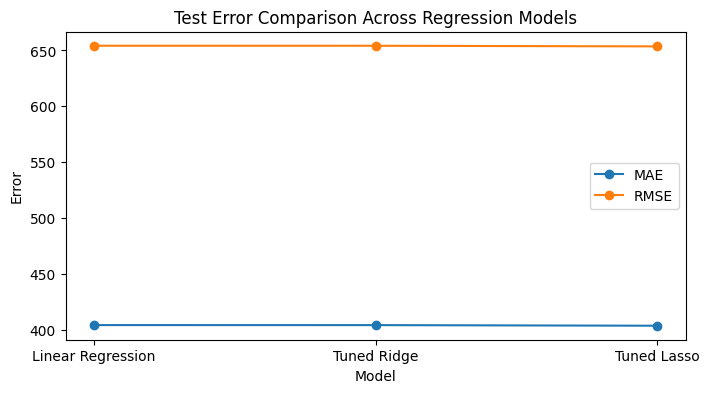

In [12]:
plot_df = results_df.set_index("model")[["MAE", "RMSE"]]

plt.figure(figsize=(8, 4))

plt.plot(plot_df.index, plot_df["MAE"], marker="o", label="MAE")
plt.plot(plot_df.index, plot_df["RMSE"], marker="o", label="RMSE")

plt.title("Test Error Comparison Across Regression Models")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend()
plt.show()

## 12. Extract best tuned coefficients


In [13]:
feature_names = ridge_search.best_estimator_.named_steps["preprocessor"].get_feature_names_out() # getting feature names after preprocessing (scaling and encoding)

ridge_best_coefs = ridge_search.best_estimator_.named_steps["regressor"].coef_
lasso_best_coefs = lasso_search.best_estimator_.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
    "feature" : feature_names,
    "ridge_coef" : ridge_best_coefs,
    "lasso_coef" : lasso_best_coefs
})

coef_df["ridge_abs"] = np.abs(coef_df["ridge_coef"]) # calculating absolute values of Ridge coefficients to compare feature importance without regard to direction (positive or negative)
coef_df["lasso_abs"] = np.abs(coef_df["lasso_coef"]) # calculating absolute values of Lasso coefficients to compare feature importance without regard to direction (positive or negative)

coef_df.sort_values("ridge_abs", ascending = False).head(20)

,feature,ridge_coef,lasso_coef,ridge_abs,lasso_abs
2,num__chronic_condition_count,684.973452,685.057114,684.973452,685.057114
7,num__ip_admits,579.152242,578.625343,579.152242,578.625343
11,cat__plan_type_Medicaid,-542.425961,-527.280880,542.425961,527.280880
12,cat__plan_type_Medicare Advantage,-413.585467,-395.001213,413.585467,395.001213
6,num__ed_visits,261.628722,261.299086,261.628722,261.299086
10,cat__region_Urban,-105.399607,-92.046963,105.399607,92.046963
0,num__age,63.403640,62.650430,63.403640,62.650430
3,num__engagement_score,-62.302204,-62.770897,62.302204,62.770897
9,cat__region_Suburban,-47.865148,-28.466723,47.865148,28.466723
4,num__pcp_attributed_24mo,-39.621657,-39.067829,39.621657,39.067829


In [14]:
coef_df.sort_values(
    "lasso_abs",  # Sort by Lasso coefficient magnitude
    ascending=False  # Show largest absolute Lasso coefficients first
).head(20)  # Display strongest tuned Lasso coefficients

,feature,ridge_coef,lasso_coef,ridge_abs,lasso_abs
2,num__chronic_condition_count,684.973452,685.057114,684.973452,685.057114
7,num__ip_admits,579.152242,578.625343,579.152242,578.625343
11,cat__plan_type_Medicaid,-542.425961,-527.280880,542.425961,527.280880
12,cat__plan_type_Medicare Advantage,-413.585467,-395.001213,413.585467,395.001213
6,num__ed_visits,261.628722,261.299086,261.628722,261.299086
10,cat__region_Urban,-105.399607,-92.046963,105.399607,92.046963
3,num__engagement_score,-62.302204,-62.770897,62.302204,62.770897
0,num__age,63.403640,62.650430,63.403640,62.650430
4,num__pcp_attributed_24mo,-39.621657,-39.067829,39.621657,39.067829
9,cat__region_Suburban,-47.865148,-28.466723,47.865148,28.466723


## Tuned Coefficient Interpretation

The coefficient table compares the fitted Ridge and Lasso coefficients after tuning alpha through cross-validation.

Ridge shrinks coefficients toward zero but usually keeps all features in the model.

Lasso can shrink some coefficients exactly to zero, which creates model-specific sparsity.

Because numeric predictors are standardized, numeric coefficients represent the expected change in predicted monthly cost for a one-standard-deviation increase in the predictor.

Categorical dummy coefficients are interpreted relative to their omitted reference categories.

These coefficients are model-based associations, not causal effects.

## 13. Check Lasso sparsity

In [15]:
num_lasso_zero = (coef_df["lasso_coef"] == 0).sum()  # Count coefficients set exactly to zero by Lasso
total_features = len(coef_df)  # Count total transformed features
percent_zeroed = num_lasso_zero / total_features  # Calculate share of zeroed coefficients

print("Lasso coefficients equal to zero:", num_lasso_zero)  # Print number of zero coefficients
print("Total features:", total_features)  # Print total feature count
print("Percent zeroed:", percent_zeroed)  # Print share of coefficients set to zero


Lasso coefficients equal to zero: 1
Total features: 13
Percent zeroed: 0.07692307692307693


## Lasso Sparsity Interpretation

The tuned Lasso model set 1 out of 13 transformed coefficients exactly to zero.

This means Lasso created a small amount of model-specific sparsity under the selected alpha value.

However, a zeroed coefficient does not prove that the predictor is universally irrelevant. It only means that, under this feature set, training sample, preprocessing setup, and selected alpha, Lasso did not retain that feature.

Because Lasso can behave differently when predictors are correlated, sparsity should be interpreted cautiously.

## 14. Findings

The purpose of this notebook was to tune Ridge and Lasso regularized regression models for predicting monthly member cost.

The target variable was `monthly_cost`.

The predictor set excluded `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables. `member_id` was excluded because it is only an identifier. `high_cost_member` was excluded because it is derived from `monthly_cost` and would create target leakage. `awv_completed` was excluded to keep the cost prediction model focused on member characteristics, risk, access, engagement, and utilization. Grouped and redundant engineered features were excluded to keep the tuning comparison consistent with the previous cost regression notebooks.

Ridge and Lasso were tuned using 5-fold cross-validation rather than manually chosen alpha values.

Both models were tuned using negative root mean squared error, so the selected alpha values were based on estimated RMSE performance during cross-validation.

The tuned models were then evaluated on the held-out test set and compared against plain Linear Regression using MAE, RMSE, and R².

If tuned Ridge or Lasso outperformed plain Linear Regression, that suggests regularization improved generalization for this synthetic dataset. If performance was similar across models, that suggests the baseline linear model was already reasonably stable.

Lasso coefficients equal to zero should be interpreted as model-specific sparsity under the selected penalty, not proof that those predictors are universally irrelevant.

The feature set was kept consistent with the previous cost regression notebooks by excluding leakage-prone fields, full-dataset grouped features, and redundant engineered variables.

Tuned Ridge and Tuned Lasso were selected using 5-fold cross-validation on the training data only.

The final model comparison was performed on the held-out test set, which was not used for alpha selection.

Any performance improvement from tuning should be interpreted based on practical size, not just whether the metric is numerically better.

Because this is synthetic data, the observed relationships reflect the assumptions built into the data-generation process and should not be interpreted as real-world causal evidence.